In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def inspect_np2_raw(path, n_channels=384, dtype=np.int16, plot_snippet=True):
    print(f"--- Inspecting file: {path} ---")
    
     
    # Basic file checks
     
    if not os.path.exists(path):
        print("ERROR: File does not exist.")
        return
    
    file_size = os.path.getsize(path)
    bytes_per_sample = np.dtype(dtype).itemsize
    print(f"File size: {file_size:,} bytes")
    
    if file_size % (n_channels * bytes_per_sample) != 0:
        print("WARNING: File size is NOT divisible by n_channels * 2 bytes")
        print(f"Expected divisor: {n_channels * bytes_per_sample}")
    else:
        print("OK: File size divisible by (n_channels × 2 bytes).")
    
     
    # Compute number of samples
     
    n_samples = file_size // (n_channels * bytes_per_sample)
    print(f"Computed number of samples: {n_samples:,}")
    
     
    # Read first chunk to inspect values
     
    with open(path, "rb") as f:
        head = np.frombuffer(f.read(20 * bytes_per_sample), dtype=dtype)
    
    print("First 20 int16 values:", head)
    
     
    # Try to memory-map as (n_samples, n_channels)
     
    try:
        mm = np.memmap(path, dtype=dtype, mode="r", shape=(n_samples, n_channels))
        print("OK: Successfully memmapped into shape =", mm.shape)
    except Exception as e:
        print("ERROR: Could not reshape memmap:", e)
        return
    
     
    # Look at first few samples for header-like patterns
     
    print("First few samples of channel 0:", mm[:10, 0])
    print("First few samples of channel 1:", mm[:10, 1])
    
    # Heuristic warning if values look non-noisy / patterned
    if np.all(head == head[0]):
        print("WARNING: First 20 values are identical. Possible header or zero-padding?")
    
     
    # Plot snippet for interleaving sanity
     
    if plot_snippet:
        snippet = mm[1000:2000, :]   # 1000 samples
        plt.figure(figsize=(10,4))
        plt.title("Interleaving check: channels 0, 1, 2")
        plt.plot(snippet[:,0], label="ch0")
        plt.plot(snippet[:,1], label="ch1")
        plt.plot(snippet[:,2], label="ch2")
        plt.legend()
        plt.show()
    
    print("Done.")

--- Inspecting file: V:/neuropixels_2025/npx09/2025_12_09_small_box_test/data/np2-a-ephys_2025-12-09T16_29_10.raw ---
File size: 89,062,179,840 bytes
OK: File size divisible by (n_channels × 2 bytes).
Computed number of samples: 115,966,380
First 20 int16 values: [3954 3954 3954 3954 3954 3954 3954 3954 3954 3954 3954 3954 3954 3954
 3954 3954 3954 3954 3954 3954]
OK: Successfully memmapped into shape = (115966380, 384)
First few samples of channel 0: [3954 3954 3954 3954 3954 3954 3954 3954 3954 3954]
First few samples of channel 1: [3954 3954 3954 3954 3954 3954 3954 3954 3954 3954]


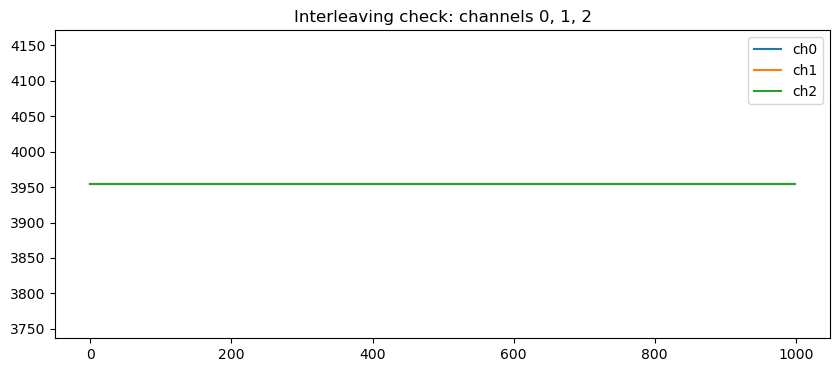

Done.


In [2]:
inspect_np2_raw(path="V:/neuropixels_2025/npx09/2025_12_09_small_box_test/data/np2-a-ephys_2025-12-09T16_29_10.raw")

Snippet stats (later in recording):
  ch 0: mean=3130.2, std=23.3, min=3076, max=3196
  ch 1: mean=3087.0, std=23.2, min=3025, max=3164
  ch 2: mean=3044.5, std=25.5, min=2981, max=3139


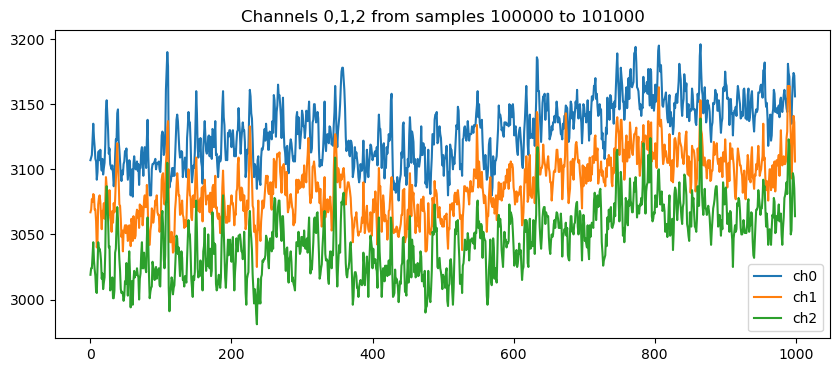

: 

In [ ]:
path = r"V:/neuropixels_2025/npx09/2025_12_09_small_box_test/data/np2-a-ephys_2025-12-09T16_29_10.raw"
n_channels = 384
dtype = np.int16

# Re-open memmap
file_size = os.path.getsize(path)
n_samples = file_size // (n_channels * np.dtype(dtype).itemsize)
mm = np.memmap(path, dtype=dtype, mode="r", shape=(n_samples, n_channels))

# Look at samples a bit later in time
start = 100000      # for example, 10k samples in
stop = start + 1000

print("Snippet stats (later in recording):")
for ch in range(3):
    x = mm[start:stop, ch]
    print(f"  ch {ch}: mean={x.mean():.1f}, std={x.std():.1f}, min={x.min()}, max={x.max()}")

plt.figure(figsize=(10,4))
plt.title(f"Channels 0,1,2 from samples {start} to {stop}")
for ch in range(3):
    plt.plot(mm[start:stop, ch], label=f"ch{ch}")
plt.legend()
plt.show()